# TP 1 : Implémentation d'un RNN from scratch et application à une série temporelle réelle

Installation des librairies

In [249]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

### Partie 1 : Implémentation d'un RNN from scratch.

1. Écrire une fonction qui calcule l'état caché de h_t en fonction de x_t, de l'état caché précédent, et des poids de la cellule RNN.

In [250]:
def forward_hidden_state(x_t, h_prev, W_xh, W_hh, b_h):
    h_t = np.tanh(W_xh @ x_t + W_hh @ h_prev + b_h)
    return h_t

2. Écrire une fonction qui calcule la sortie y_t de la cellule en fonction de h_t, et des poids de la cellule RNN.

In [251]:
def output(h_t, W_hy, b_y):
    y = np.dot(W_hy,h_t) + b_y
    #y_t = 1+ (1+np.exp(-y))
    y_t = np.dot(W_hy,h_t) + b_y
    return y_t


3. Regrouper les fonctions précédentes dans une fonction globale, qui calcule l'état caché et la sortie de la cellulle au pas de temps t.

In [252]:
def forward_rnn_cell(x_t, h_prev, W_xh, W_hh, b_h, W_hy, b_y):
    # A compléter - Calcul de h_t et y_t
    h_t = forward_hidden_state(x_t, h_prev, W_xh, W_hh, b_h)
    y_t = output(h_t, W_hy, b_y)
    return h_t, y_t

4. Pour une série temporelle X de longueur T, écrire la fonction qui fait passer cette entrée dans la cellule RNN, et retourne les états cachés et les sorties sur l'ensemble des pas de temps.

In [253]:
def forward_rnn(X, h0, W_xh, W_hh, b_h, W_hy, b_y):
    H = [h0]
    Y = []
    for x_t in X:
        # Calcul de l'état caché
        h_t = np.tanh(x_t @ W_xh + H[-1] @ W_hh + b_h)
        # Calcul de la sortie
        y_t = h_t @ W_hy + b_y
        H.append(h_t)
        Y.append(y_t)

    H = np.array(H[1:])
    Y = np.array(Y)
    return Y, H

### Partie 2 : Application à l'exemple du TD (Inférence)

5. Vérifier votre modèle en l'appliquant avec les poids du réseau du TD1, réalisé à la main.

In [254]:
import numpy as np

# Données
x_1 = np.array([[0.5], [-0.3]])
x_2 = np.array([[-0.1], [0.7]])
X   = np.array([[[0.5], [-0.3]], [[-0.1], [0.7]]])

# Paramètres
W_xh = np.array([[0.1, 0.2], [-0.3, 0.4], [0.5, -0.2]])
W_hh = np.array([[0.2, -0.1, 0.3], [0.4, 0.5, -0.2], [-0.3, 0.1, 0.2]])
W_hy = np.array([[0.7, -0.5, 0.6]])
b_h  = np.array([[0.1], [-0.2], [0.1]])
b_y  = np.array([[0.1]])
h0   = np.array([[0.0], [0.0], [0.0]])

# Forward pass
def forward_rnn(X, h0, W_xh, W_hh, b_h, W_hy, b_y):
    H = []
    Y_pred = []
    h_prev = h0
    for x_t in X:
        h_t = np.tanh(W_xh @ x_t + W_hh @ h_prev + b_h)
        y_t = W_hy @ h_t + b_y
        H.append(h_t)
        Y_pred.append(y_t)
        h_prev = h_t
    return Y_pred, H

# Résultats
Y_pred, H = forward_rnn(X, h0, W_xh, W_hh, b_h, W_hy, b_y)

print(f"h1 : {H[0].T}")
print(f"y1 : {Y_pred[0]}")
print(f"h2 : {H[1].T}")
print(f"y2 : {Y_pred[1]}")

h1 : [[ 0.08975778 -0.43819931  0.38847268]]
y1 : [[0.61501371]]
h2 : [[ 0.38703958 -0.14975625 -0.0828623 ]]
y2 : [[0.39608845]]


### Partie 3 : Implémentation de l'optimisation du RNN

6. Écrire une fonction qui calcule l'erreur quadratique entre une séquence prédite et une séquence réelle.

In [255]:
def compute_loss(Y_pred, Y_true):

    loss = np.mean((Y_pred - Y_true) ** 2)
    return loss

7. Calcul du gradient du RNN - Compléter la foncton suivante en vous aidant du gradient calculé en séance de TD.

In [256]:
def compute_gradients(X, Y_true, H, Y_pred, W_xh, W_hh, b_h, W_hy, b_y):
    dL_dW_xh = np.zeros_like(W_xh)
    dL_dW_hh = np.zeros_like(W_hh)
    dL_db_h = np.zeros_like(b_h)
    dL_dW_hy = np.zeros_like(W_hy)
    dL_db_y = np.zeros_like(b_y)
    dL_dh_next = np.zeros_like(H[0])

    N = len(X)

    for t in reversed(range(N)):
        dy = (2 / N) * (Y_pred[t] - Y_true[t])

        dL_dW_hy += dy * H[t].T
        dL_db_y += dy

        dh = W_hy.T * dy + dL_dh_next
        dtanh = (1 - H[t] ** 2) * dh

        dL_db_h += dtanh
        dL_dW_xh += dtanh @ X[t].T
        dL_dW_hh += dtanh @ (H[t - 1].T if t > 0 else np.zeros_like(H[0]).T)
        dL_dh_next = W_hh.T @ dtanh

    gradients = [dL_dW_xh, dL_dW_hh, dL_db_h, dL_dW_hy, dL_db_y]
    return [np.clip(g, -0.5, 0.5) for g in gradients]

8. Écrire une fonction qui mets à jour les poids du réseau de neurones en utilisant la fonction de calcul des gradients.

In [257]:
def update_weights(
    X_train, Y_train, h0, W_xh, W_hh, b_h, W_hy, b_y, learning_rate
):
    # Calcul des sorties du réseau
    Y_pred, H = forward_rnn(X_train, h0, W_xh, W_hh, b_h, W_hy, b_y)

    # Calcul et affichage de la loss (MSE)
    loss = compute_loss(Y_pred, Y_train)
    print(f"Loss: {loss}")

    # Récupération des gradients
    dL_dW_xh, dL_dW_hh, dL_db_h, dL_dW_hy, dL_db_y = compute_gradients(
        X_train, Y_train, H, Y_pred, W_xh, W_hh, b_h, W_hy, b_y
    )

    # Mise à jour des poids (gradient descent)
    W_xh_new = W_xh - learning_rate * dL_dW_xh
    W_hh_new = W_hh - learning_rate * dL_dW_hh
    b_h_new  = b_h  - learning_rate * dL_db_h
    W_hy_new = W_hy - learning_rate * dL_dW_hy
    b_y_new  = b_y  - learning_rate * dL_db_y

    return W_xh_new, W_hh_new, b_h_new, W_hy_new, b_y_new

9. Écrire une fonction qui optimise le RNN en réalisant la mise à jour des poids pour un nombre d'époques donné.

In [258]:
def optimize_rnn(X_train, Y_train, h0, W_xh, W_hh, b_h, W_hy, b_y, epochs, learning_rate):
    for epoch in range(epochs):
        W_xh, W_hh, b_h, W_hy, b_y = update_weights(
            X_train, Y_train, h0, W_xh, W_hh, b_h, W_hy, b_y, learning_rate
        )
        if epoch % 10 == 0:
            Y_pred, _ = forward_rnn(X_train, h0, W_xh, W_hh, b_h, W_hy, b_y)
            loss = compute_loss(Y_pred, Y_train)
            print(f"Epoch {epoch}/{epochs} - Loss: {loss:.4f}")

    return W_xh, W_hh, b_h, W_hy, b_y

### Partie 4 : Application à l'exemple du TD (Optimisation)

10. Optimisation du réseau sur l'exemple du TD - Utiliser les valeurs rélles du TD pour optimiser le RNN.

In [259]:
Y_true = np.array([[[0.42]],[[0.5]]])
# Optimisation
W_xh_opt, W_hh_opt, b_h_opt, W_hy_opt, b_y_opt = optimize_rnn(
    X, Y_true, h0, W_xh, W_hh, b_h, W_hy, b_y, epochs=100, learning_rate=0.0001
)
# Vérification
Y_pred, H = forward_rnn(X, h0, W_xh_opt, W_hh_opt, b_h_opt, W_hy_opt, b_y_opt)



Loss: 0.024413979739356335
Epoch 0/100 - Loss: 0.0244
Loss: 0.02440799592589389
Loss: 0.024402014093155174
Loss: 0.02439603424008918
Loss: 0.024390056365645646
Loss: 0.024384080468775094
Loss: 0.024378106548428917
Loss: 0.024372134603559303
Loss: 0.02436616463311922
Loss: 0.024360196636062405
Loss: 0.02435423061134347
Epoch 10/100 - Loss: 0.0243
Loss: 0.024348266557917803
Loss: 0.024342304474741627
Loss: 0.024336344360771932
Loss: 0.02433038621496646
Loss: 0.024324430036283918
Loss: 0.02431847582368358
Loss: 0.024312523576125764
Loss: 0.024306573292571364
Loss: 0.024300624971982262
Loss: 0.024294678613321026
Epoch 20/100 - Loss: 0.0243
Loss: 0.024288734215551045
Loss: 0.024282791777636495
Loss: 0.02427685129854236
Loss: 0.024270912777234466
Loss: 0.024264976212679316
Loss: 0.024259041603844306
Loss: 0.02425310894969764
Loss: 0.024247178249208204
Loss: 0.02424124950134577
Loss: 0.024235322705080886
Epoch 30/100 - Loss: 0.0242
Loss: 0.024229397859384813
Loss: 0.024223474963229713
Loss: 0

### Partie 5 : Application à une série temporelle réelle (Optimisation + Inférence)

11. Fixer les hyperparamètres de votre cellulle RNN pour pouvoir traiter des entrées de taille 4, avec une couche cachée de taille 100x100, et une sortie unidimensionnelle. On entraînera le réseaux sur 100 epoques et avec un learning rate égale à 0.002.

In [260]:
# Dimensions de la cellule RNN
h_size = 100
x_size = 4
y_size = 1

# Hyperparamètres
learning_rate = 0.002
epochs = 100

12. Récupérer les données du jeu de données

In [261]:
# A compléter - Import des données
import pandas as pd

df = pd.read_csv('heart_rate.csv')
print(df.head())
print(f"Shape : {df.shape}")


        T1       T2       T3       T4
0  84.2697  91.4634  60.4839  59.2885
1  84.2697  91.4634  60.4839  59.2885
2  84.0619  91.1834  60.4606  59.2885
3  85.6542  91.8788  60.3391  58.8973
4  87.2093  91.1772  60.0762  58.4359
Shape : (1800, 4)


13. La fonction ci dessous transforme une série temporelle en une entrée à seq_length dimensions et une sortie unidimensionnelle. Appliquer cette fonction à vos jeux de données pour obtenir une entrée et une sortie compatibles avec les vecteurs de poids de la cellulle RNN. Assurez vous de bien comprendre ce que fais exctement cette fonction. Pourquoi réalise-t-on cette opération ?

In [262]:
from sklearn.preprocessing import StandardScaler

def create_sequences(time_series, seq_length):
    X = np.array([time_series[i : i + seq_length] for i in range(len(time_series) - seq_length)])
    Y = np.array([time_series[i + seq_length] for i in range(len(time_series) - seq_length)])

    X = X.reshape(X.shape[0], seq_length, 1)
    Y = Y.reshape(Y.shape[0], 1)

    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()
    X = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
    Y = scaler_Y.fit_transform(Y.reshape(-1, Y.shape[-1])).reshape(Y.shape)

    return X, Y, scaler_X, scaler_Y

time_series = df.iloc[:, 1].values

# Application avec seq_length = 4 (= x_size)
X, Y, scaler_X, scaler_Y = create_sequences(time_series, seq_length=4)

print(f"X shape : {X.shape}")
print(f"Y shape : {Y.shape}")

X shape : (1796, 4, 1)
Y shape : (1796, 1)


14. Découper vos jeux de données en jeu d'entraînement et de test

In [263]:
# A compléter - Découpage en jeu d'entraînement et de test
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Y_train : {Y_train.shape}")
print(f"Y_test  : {Y_test.shape}")

X_train : (1436, 4, 1)
X_test  : (360, 4, 1)
Y_train : (1436, 1)
Y_test  : (360, 1)


15. Initialisation des vecteurs de poids - Complétez les différentes initialisations avec les dimensions correspondantes.

In [264]:
# A compléter - Initialisation des poids
W_xh = np.random.randn(h_size, x_size) * np.sqrt(2.0 / sum((h_size, x_size)))
W_hh = np.random.randn(h_size, h_size) * np.sqrt(2.0 / sum((h_size, x_size)))
W_hy = np.random.randn(y_size, h_size) * np.sqrt(2.0 / sum((y_size, h_size)))
b_h  = np.zeros((h_size, 1))
b_y  = np.zeros((y_size, 1))
h0   = np.zeros((h_size, 1))

print(f"W_xh : {W_xh.shape}")
print(f"W_hh : {W_hh.shape}")
print(f"W_hy : {W_hy.shape}")
print(f"b_h  : {b_h.shape}")
print(f"b_y  : {b_y.shape}")
print(f"h0   : {h0.shape}")

W_xh : (100, 4)
W_hh : (100, 100)
W_hy : (1, 100)
b_h  : (100, 1)
b_y  : (1, 1)
h0   : (100, 1)


16. Visualisation des données - La fonction suivante n'est pas à compléter. Elle permet de tracer sur le même graphique, les données réelles et les données prédites pour comparaison. Testez cette fonction en comparant les valeurs réelles à elles-mêmes.

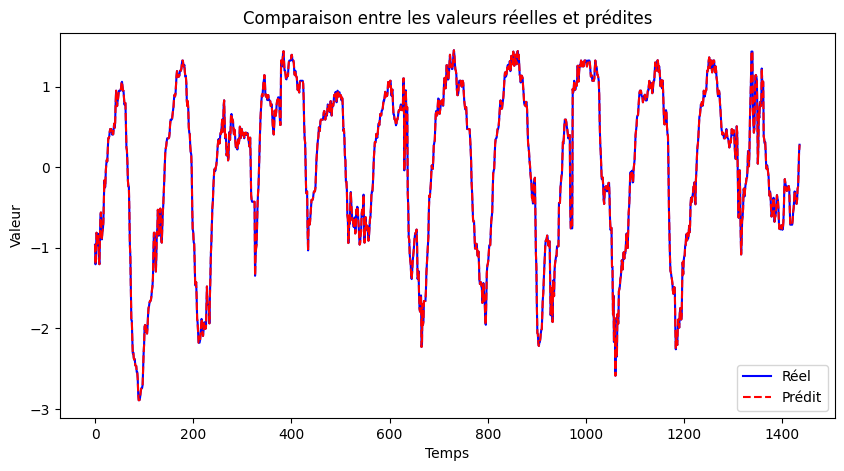

In [265]:
import matplotlib.pyplot as plt

def plot_predictions(y_true, y_pred):
    y_true = y_true.ravel()
    time_steps = np.arange(len(y_true))

    plt.figure(figsize=(10, 5))
    plt.plot(time_steps, y_true, label="Réel", color="blue")
    plt.plot(time_steps, y_pred.flatten(), label="Prédit", color="red", linestyle="dashed")
    plt.legend()
    plt.xlabel("Temps")
    plt.ylabel("Valeur")
    plt.title("Comparaison entre les valeurs réelles et prédites")
    plt.show()

# Test : superposition de Y_train à lui-même
plot_predictions(Y_train, Y_train)

17. Comme précédemment, réaliser l'optimisation de la cellule RNN à partir des données d'entraînement en utilisant la fonction optimize_rnn.

In [266]:


# Optimisation du RNN
W_xh, W_hh, b_h, W_hy, b_y = optimize_rnn(
    X_train, Y_train, h0, W_xh, W_hh, b_h, W_hy, b_y,
    epochs=epochs,
    learning_rate=learning_rate
)


Loss: 2.121790309538392
Epoch 0/100 - Loss: 1.8395
Loss: 1.8394704742010153
Loss: 1.8985571095558973
Loss: 1.8472184576246469
Loss: 1.9285409590082443
Loss: 1.8864163840230583
Loss: 1.9388958735595245
Loss: 1.9591241023439219
Loss: 2.205942228837741
Loss: 2.1632441474178776
Loss: 2.0718948546412137
Epoch 10/100 - Loss: 1.9455
Loss: 1.9454911750584047
Loss: 1.942967879046659
Loss: 1.9368009204913
Loss: 1.9879147396380112
Loss: 1.9696360982638557
Loss: 1.9359232771546333
Loss: 1.8940610499700634
Loss: 1.9872703703244863
Loss: 1.9717785635631184
Loss: 1.9651480617469224
Epoch 20/100 - Loss: 1.9682
Loss: 1.968192629286207
Loss: 1.9693727030576669
Loss: 1.9561651527464052
Loss: 1.9493059586436416
Loss: 1.9007797612191937
Loss: 1.9406948953493635
Loss: 1.9019499446513746
Loss: 1.929310955853699
Loss: 1.9237135936963756
Loss: 1.9365736763600094
Epoch 30/100 - Loss: 1.9438
Loss: 1.9438339518618701
Loss: 1.9601372090059885
Loss: 1.9803658118270973
Loss: 1.8958223454279308
Loss: 1.91599068620948

18. Tester votre RNN optimisé sur les données d'entraînement. Calculer la loss associée.

Loss train : 1.9469


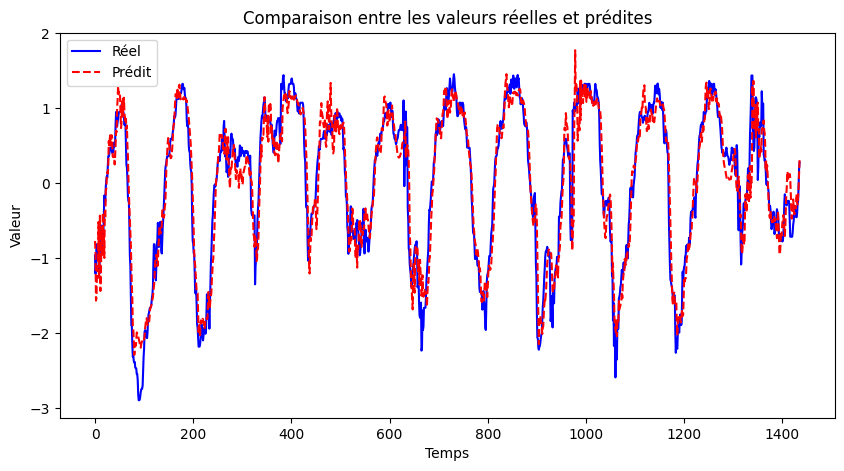

In [267]:
# Prédictions finales sur les données d'entraînement
y_pred_train, H = forward_rnn(X_train, h0, W_xh, W_hh, b_h, W_hy, b_y)

# Calcul de la loss
loss_train = compute_loss(y_pred_train, Y_train)
print(f"Loss train : {loss_train:.4f}")

# Visualisation
plot_predictions(Y_train, np.concatenate(y_pred_train))


19. Tester votre RNN sur les données de test. Calculer la loss associée. Quelle remarque faites vous ?

In [268]:

# Formatage des données de test
X_test_list = [X_test[i] for i in range(len(X_test))]
Y_test_list = [Y_test[i].reshape(1, 1) for i in range(len(Y_test))]

# Prédictions finales sur les données de test
y_pred_test, H = forward_rnn(X_test_list, h0, W_xh, W_hh, b_h, W_hy, b_y)

# Calcul de la loss
loss_test = compute_loss(np.array(y_pred_test), np.array(Y_test_list))
print(f"Loss train : {loss_train:.4f}")
print(f"Loss test  : {loss_test:.4f}")




Loss train : 1.9469
Loss test  : 0.0995


20. Utiliser la fonction plot_predictions pour afficher sur le même graphique, les valeurs prédites et les valeurs réelles

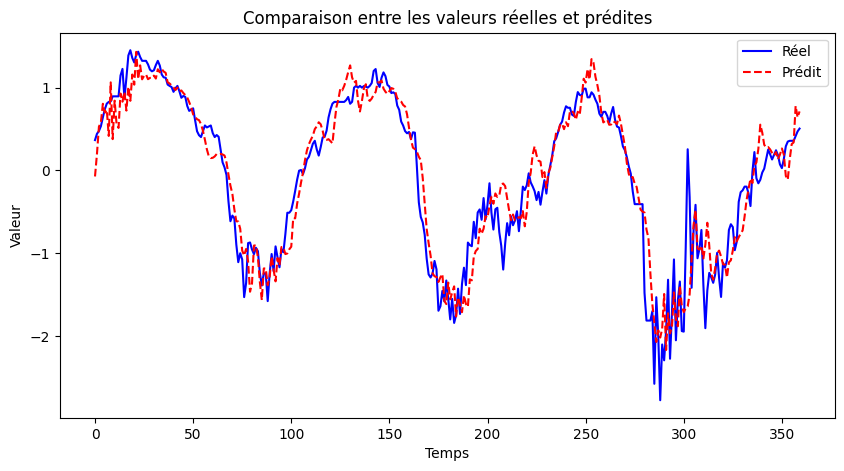

In [269]:
# Affichage des résultats sur les données de test
plot_predictions(Y_test, np.concatenate(y_pred_test))



21. Jouer sur les hyperparamètres du modèle pour oserver l'impact sur votre prédiction

Loss: 1.6664882267523888
Epoch 0/200 - Loss: 1.2560
Loss: 1.2559607309639147
Loss: 2.090638702483736
Loss: 1.3112523162509309
Loss: 1.972113550816927
Loss: 1.5145297191197538
Loss: 1.7192597496323903
Loss: 1.7768723285221957
Loss: 1.7923724804626795
Loss: 1.7735862722480553
Loss: 1.7836582891414239
Epoch 10/200 - Loss: 1.7253
Loss: 1.725342685454712
Loss: 1.9298844396748926
Loss: 1.716066128296204
Loss: 1.9960087327583338
Loss: 1.6178849003614726
Loss: 2.0654631278691373
Loss: 1.5224418787810183
Loss: 2.5327307436669826
Loss: 1.464556229391023
Loss: 2.445100611008694
Epoch 20/200 - Loss: 1.8549
Loss: 1.8548893193479126
Loss: 1.9074009852696263
Loss: 1.8966299232552088
Loss: 1.9322320454173174
Loss: 1.87773197509565
Loss: 1.8955569473557852
Loss: 1.9538165175578488
Loss: 1.8539007118254462
Loss: 1.5454388218626225
Loss: 1.896139163252801
Epoch 30/200 - Loss: 1.7251
Loss: 1.7250738201150775
Loss: 1.900492870856002
Loss: 1.813818828168149
Loss: 1.9063946115298724
Loss: 1.858452844365329
L

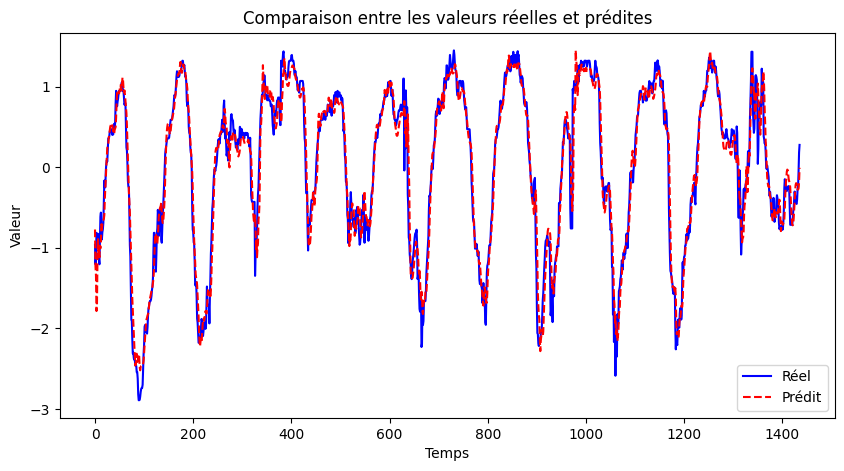

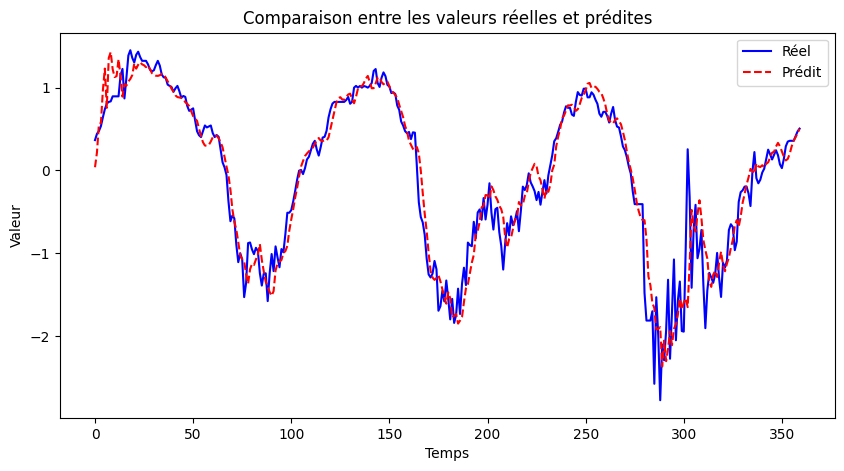

In [273]:
# Hyperparamètres à tester
h_size        = 150
x_size        = 4
y_size        = 1
learning_rate = 0.005
epochs        = 200

# Réinitialisation des poids
W_xh = np.random.randn(h_size, x_size) * np.sqrt(2.0 / sum((h_size, x_size)))
W_hh = np.random.randn(h_size, h_size) * np.sqrt(2.0 / sum((h_size, x_size)))
W_hy = np.random.randn(y_size, h_size) * np.sqrt(2.0 / sum((y_size, h_size)))
b_h  = np.zeros((h_size, 1))
b_y  = np.zeros((y_size, 1))
h0   = np.zeros((h_size, 1))

# Optimisation
W_xh, W_hh, b_h, W_hy, b_y = optimize_rnn(
    X_train, Y_train, h0, W_xh, W_hh, b_h, W_hy, b_y,
    epochs=epochs,
    learning_rate=learning_rate
)

# Évaluation
y_pred_train, _ = forward_rnn(X_train, h0, W_xh, W_hh, b_h, W_hy, b_y)
y_pred_test, _  = forward_rnn(X_test,  h0, W_xh, W_hh, b_h, W_hy, b_y)

print(f"Loss train : {compute_loss(y_pred_train, Y_train):.4f}")
print(f"Loss test  : {compute_loss(y_pred_test,  Y_test):.4f}")

plot_predictions(Y_train, np.concatenate(y_pred_train))
plot_predictions(Y_test,  np.concatenate(y_pred_test))

Dans cette section, nous testons l'impact des hyperparamètres sur les performances du RNN.
Nous faisons varier h_size, learning_rate et epochs pour observer leur effet sur la loss
et sur la qualité des prédictions.